# quiz 1


檢查Movie Reviews資料集

In [1]:
import pandas as pd
from pathlib import Path
from collections import Counter
from PIL import Image
import hashlib

In [2]:
df = pd.read_csv("dataset/Movie Reviews/IMDB Dataset.csv")

print(df.shape)
print(df.columns)

print(df["sentiment"].value_counts())
print(df.isna().sum())

(50000, 2)
Index(['review', 'sentiment'], dtype='str')
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
review       0
sentiment    0
dtype: int64


In [3]:
print("空白影評：", df["review"].str.strip().eq("").sum())
print("重複影評：", df.duplicated(subset=["review"]).sum())

label_counts = df.groupby("review")["sentiment"].nunique()
print("有不同label的影評數：", (label_counts > 1).sum())

空白影評： 0
重複影評： 418
有不同label的影評數： 0


In [4]:
df_clean = df.drop_duplicates(subset=["review"]).reset_index(drop=True)

print(df_clean.shape)
print(df_clean["sentiment"].value_counts())

(49582, 2)
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


檢查Rock-Paper-Scissors Images資料集

In [5]:
data_dir = Path("./dataset/Rock-Paper-Scissors Images")

for label in ["rock", "paper", "scissors"]:
    folder = data_dir / label

    images = [
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    print(label, len(images))

rock 726
paper 712
scissors 750


In [6]:
sizes = Counter()
modes = Counter()

for label in ["rock", "paper", "scissors"]:
    for p in (data_dir / label).iterdir():
        if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            with Image.open(p) as img:
                sizes[img.size] += 1
                modes[img.mode] += 1

print("尺寸：", sizes)
print("色彩模式：", modes)

尺寸： Counter({(300, 200): 2188})
色彩模式： Counter({'RGB': 2188})


檢查Filckr 8k Dataset資料集

In [7]:
flickr_dir = Path("./dataset/Flickr 8k Dataset")
image_dir = flickr_dir / "Images"

captions = pd.read_csv(flickr_dir / "captions.txt")

print(captions.shape)
print(captions.columns)
print(captions.head(5))

(40455, 2)
Index(['image', 'caption'], dtype='str')
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  


In [8]:
print("不同圖片數：", captions["image"].nunique())

caption_counts = captions.groupby("image").size()
print("每張圖片的caption數量分布：")
print(caption_counts.value_counts())

不同圖片數： 8091
每張圖片的caption數量分布：
5    8091
Name: count, dtype: int64


In [9]:
actual_images = {
    p.name for p in image_dir.iterdir()
    if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
}

caption_images = set(captions["image"])

missing_images = caption_images - actual_images
missing_captions = actual_images - caption_images

print("有caption，但找不到圖片：", len(missing_images))
print("有圖片，但沒有caption：", len(missing_captions))

有caption，但找不到圖片： 0
有圖片，但沒有caption： 0


In [10]:
bad_images = []
sizes = Counter()
modes = Counter()

for filename in sorted(actual_images):
    p = image_dir / filename

    try:
        with Image.open(p) as img:
            img.load()
            sizes[img.size] += 1
            modes[img.mode] += 1
    except OSError:
        bad_images.append(p)

print("無法讀取的圖片數：", len(bad_images))
print("尺寸種類數：", len(sizes))
print("色彩模式：", modes)

無法讀取的圖片數： 0
尺寸種類數： 597
色彩模式： Counter({'RGB': 8091})


In [11]:
duplicate_pairs = captions.duplicated(
    subset=["image", "caption"]
).sum()

print("額外重複的image-caption配對：", duplicate_pairs)

額外重複的image-caption配對： 10


In [12]:
repeated_rows = captions[
    captions.duplicated(subset=["image", "caption"], keep=False)
]

print(repeated_rows.sort_values("image").to_string(index=False))

                    image                                                      caption
2305437797_e6c3460190.jpg                   A dog swimming with a stick in its mouth .
2305437797_e6c3460190.jpg                   A dog swimming with a stick in its mouth .
2335619125_2e2034f2c3.jpg                    A black dog is running through the snow .
2335619125_2e2034f2c3.jpg                    A black dog is running through the snow .
2441629086_52f68eb316.jpg                                 A girl peers into a window .
2441629086_52f68eb316.jpg                                 A girl peers into a window .
2737729252_b3fd9c05b1.jpg       A girl is taking a picture of another girl in a park .
2737729252_b3fd9c05b1.jpg       A girl is taking a picture of another girl in a park .
3262075846_5695021d84.jpg                           A group of men are playing rugby .
3262075846_5695021d84.jpg                           A group of men are playing rugby .
3337046794_296bd2c7e0.jpg                  

In [13]:
seen = {}
duplicate_images = []

for filename in sorted(actual_images):
    p = image_dir / filename

    with Image.open(p) as img:
        content = str(img.size).encode() + img.tobytes()

    fingerprint = hashlib.sha256(content).hexdigest()

    if fingerprint in seen:
        duplicate_images.append((seen[fingerprint], filename))
    else:
        seen[fingerprint] = filename

print("額外重複圖片數：", len(duplicate_images))

for first, repeated in duplicate_images[:5]:
    print(first, "與", repeated)

額外重複圖片數： 1
2851198725_37b6027625.jpg 與 3050606344_af711c726c.jpg


# quiz 2 基礎


In [ ]:
import torch
import importlib
from torch import nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from other_code import quiz2
importlib.reload(quiz2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [27]:
train_df, remaining_df = train_test_split(df_clean, test_size=0.2, stratify=df_clean["sentiment"], random_state=42)
val_df, test_df = train_test_split(remaining_df, test_size=0.5, stratify=remaining_df["sentiment"], random_state=42)

In [ ]:
vocab = quiz2.build_vocab(train_df["review"])

print("Vocabulary 大小：", len(vocab))
print(list(vocab.items())[:10])

Vocabulary 大小： 20000
[('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9)]


In [ ]:
Batch_size = 32

train_dataset = quiz2.ReviewDataset(train_df, vocab)
val_dataset = quiz2.ReviewDataset(val_df, vocab)
test_dataset = quiz2.ReviewDataset(test_df, vocab)

train_loader = DataLoader(train_dataset, batch_size=Batch_size, shuffle=True, collate_fn=quiz2.collate_reviews)
val_loader = DataLoader(val_dataset, batch_size=Batch_size, shuffle=False, collate_fn=quiz2.collate_reviews)
test_loader = DataLoader(test_dataset, batch_size=Batch_size, shuffle=False,collate_fn=quiz2.collate_reviews)

Epoch 1 | train loss 0.6178, acc 0.6664 | val loss 0.5826, acc 0.7194
Epoch 2 | train loss 0.5113, acc 0.7690 | val loss 0.4960, acc 0.7787
Epoch 3 | train loss 0.4443, acc 0.8127 | val loss 0.4845, acc 0.8134
Epoch 4 | train loss 0.3836, acc 0.8397 | val loss 0.4794, acc 0.8276
Epoch 5 | train loss 0.3490, acc 0.8600 | val loss 0.4741, acc 0.8118
Epoch 6 | train loss 0.3277, acc 0.8705 | val loss 0.4393, acc 0.8263
Epoch 7 | train loss 0.2890, acc 0.8888 | val loss 0.4845, acc 0.7953
Epoch 8 | train loss 0.2730, acc 0.8990 | val loss 0.5099, acc 0.8009
Epoch 9 | train loss 0.2522, acc 0.9075 | val loss 0.5119, acc 0.7892
Validation loss 連續 3 輪沒有改善，停止訓練。


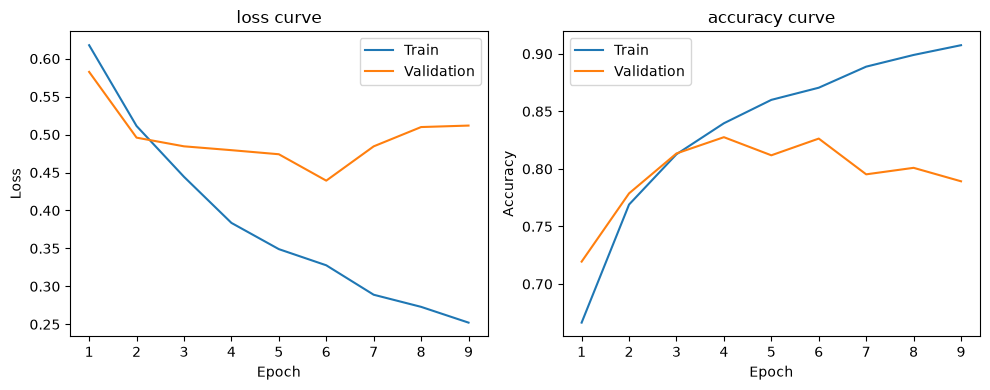

In [ ]:
Learning_rate = 0.001
Epochs = 20

model = quiz2.RNNClassifier(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=Learning_rate)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz2.train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = quiz2.evaluate(model, val_loader, criterion, device)
    

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "./checkpoints/rnn_best.pt")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Validation loss 連續 3 輪沒有改善，停止訓練。")
        break

quiz2.plot_history(history, result_path="./results/rnn")

Test loss：0.4195
Test accuracy：0.8328
Test macro-F1：0.8327


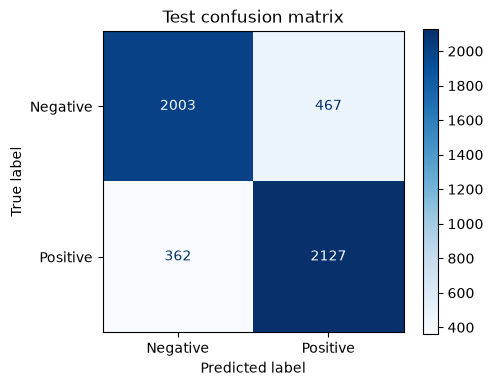

In [ ]:
model.load_state_dict(torch.load("./checkpoints/rnn_best.pt", map_location=device, weights_only=True))
test_loss, test_acc, test_f1, cm = quiz2.evaluate(model, test_loader, criterion, device)

print(f"Test loss：{test_loss:.4f}")
print(f"Test accuracy：{test_acc:.4f}")
print(f"Test macro-F1：{test_f1:.4f}")
quiz2.plot_confusion_matrix(cm, result_path="results/rnn")

# quiz 2 進階

Epoch 1 | train loss 0.5201, acc 0.7445 | val loss 0.3999, acc 0.8191
Epoch 2 | train loss 0.3263, acc 0.8697 | val loss 0.3544, acc 0.8747
Epoch 3 | train loss 0.2400, acc 0.9070 | val loss 0.2841, acc 0.8846
Epoch 4 | train loss 0.1794, acc 0.9337 | val loss 0.2913, acc 0.8923
Epoch 5 | train loss 0.1257, acc 0.9548 | val loss 0.2999, acc 0.8949
Epoch 6 | train loss 0.0869, acc 0.9708 | val loss 0.3630, acc 0.8808
Validation loss 連續 3 輪沒有改善，停止訓練。


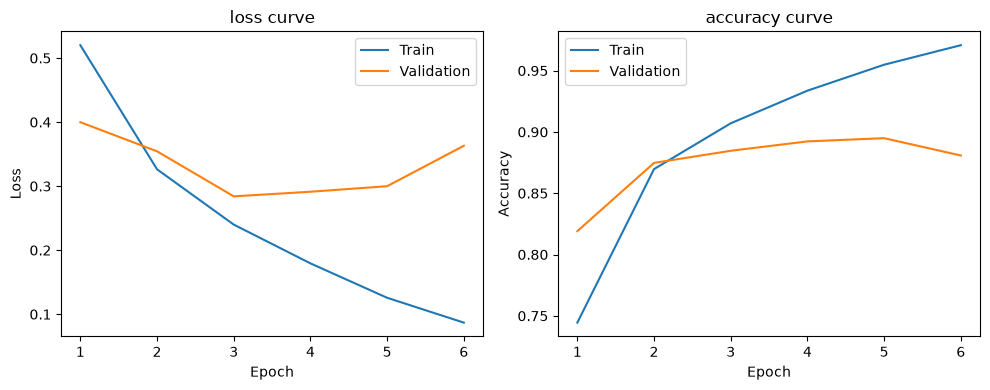

In [ ]:
model = quiz2.LSTMClassifier(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=Learning_rate)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz2.train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = quiz2.evaluate(model, val_loader, criterion, device)
    

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "./checkpoints/lstm_best.pt")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Validation loss 連續 3 輪沒有改善，停止訓練。")
        break

quiz2.plot_history(history, result_path="./results/lstm")

Test loss：0.2779
Test accuracy：0.8913
Test macro-F1：0.8913


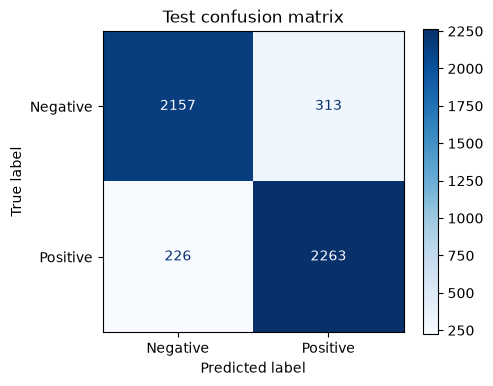

In [ ]:
model.load_state_dict(torch.load("./checkpoints/lstm_best.pt", map_location=device, weights_only=True))
test_loss, test_acc, test_f1, cm = quiz2.evaluate(model, test_loader, criterion, device)

print(f"Test loss：{test_loss:.4f}")
print(f"Test accuracy：{test_acc:.4f}")
print(f"Test macro-F1：{test_f1:.4f}")
quiz2.plot_confusion_matrix(cm, result_path="results/lstm")

# quiz 3 基礎

In [85]:
import importlib
from PIL import Image
from torch.utils.data import DataLoader
from other_code import quiz3

importlib.reload(quiz3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [78]:
train_samples, val_samples, test_samples, class_to_idx = (quiz3.prepare_splits("./dataset/Rock-Paper-Scissors Images"))

for name, samples in [
    ("train", train_samples),
    ("validation", val_samples),
    ("test", test_samples)
]:
    print(name, len(samples))

print("類別對照：", class_to_idx)

train 1750
validation 219
test 219
類別對照： {'rock': 0, 'paper': 1, 'scissors': 2}


In [ ]:
Batch_size = 32

vit_model, vit_train_transform, vit_eval_transform = quiz3.create_vit()

train_dataset = quiz3.ImageDataset(train_samples, vit_train_transform)
val_dataset = quiz3.ImageDataset(val_samples, vit_eval_transform)
test_dataset = quiz3.ImageDataset(test_samples, vit_eval_transform)

train_loader = DataLoader(train_dataset, batch_size=Batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=Batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=Batch_size, shuffle=False, num_workers=0)

Epoch 1 | train loss 0.4892, acc 0.8183 | val loss 0.1758, acc 0.9726
Epoch 2 | train loss 0.1455, acc 0.9720 | val loss 0.1000, acc 0.9909
Epoch 3 | train loss 0.0926, acc 0.9846 | val loss 0.0756, acc 0.9863
Epoch 4 | train loss 0.0696, acc 0.9869 | val loss 0.0633, acc 0.9954
Epoch 5 | train loss 0.0490, acc 0.9926 | val loss 0.0487, acc 0.9909
Epoch 6 | train loss 0.0413, acc 0.9954 | val loss 0.0538, acc 0.9954
Epoch 7 | train loss 0.0376, acc 0.9960 | val loss 0.0370, acc 1.0000
Epoch 8 | train loss 0.0331, acc 0.9971 | val loss 0.0364, acc 1.0000
Epoch 9 | train loss 0.0284, acc 0.9983 | val loss 0.0319, acc 1.0000
Epoch 10 | train loss 0.0248, acc 0.9977 | val loss 0.0318, acc 0.9954
Epoch 11 | train loss 0.0207, acc 0.9977 | val loss 0.0300, acc 0.9954
Epoch 12 | train loss 0.0222, acc 0.9977 | val loss 0.0266, acc 1.0000
Epoch 13 | train loss 0.0179, acc 0.9983 | val loss 0.0235, acc 1.0000
Epoch 14 | train loss 0.0188, acc 0.9960 | val loss 0.0278, acc 0.9954
Epoch 15 | trai

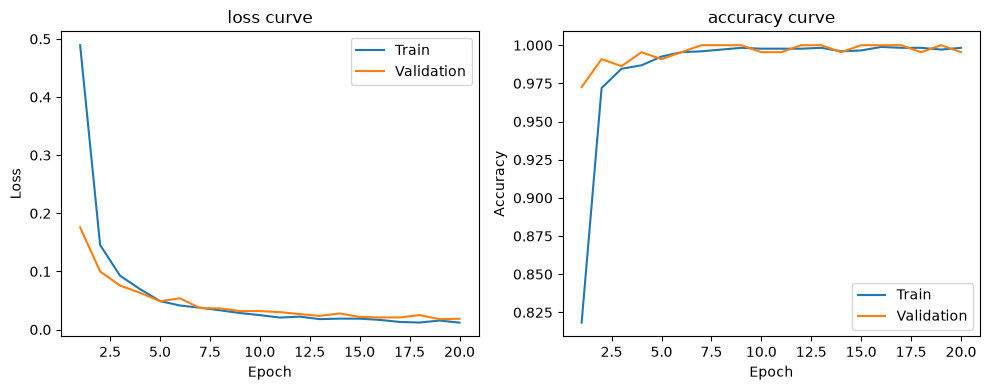

In [ ]:
Learning_rate = 0.001
Weight_decay = 0.01
Epochs = 20

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(vit_model.head.parameters(), lr=Learning_rate, weight_decay=Weight_decay)

vit_model = vit_model.to(device)
for parameter in vit_model.parameters():
    parameter.requires_grad = False

for parameter in vit_model.head.parameters():
    parameter.requires_grad = True

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz3.train_one_epoch(vit_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _, _ = quiz3.evaluate(vit_model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(vit_model.state_dict(), "./checkpoints/vit_best.pt")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Validation loss 連續 3 輪沒有改善，停止訓練。")
        break
    
quiz3.plot_history(history, result_path="./results/vit")

Test loss：0.0174
Test accuracy：0.9954
Test macro-F1：0.9955


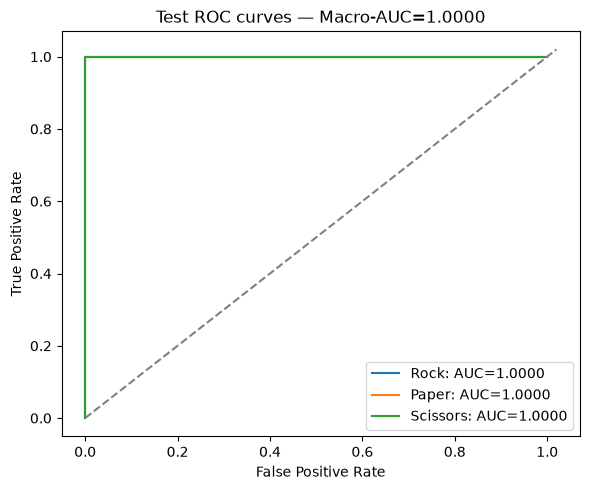

In [83]:
vit_model.load_state_dict(torch.load("./checkpoints/vit_best.pt", map_location=device, weights_only=True))
test_loss, test_acc, test_f1, test_auc, y_true, y_prob = quiz3.evaluate(vit_model, test_loader, criterion, device)

print(f"Test loss：{test_loss:.4f}")
print(f"Test accuracy：{test_acc:.4f}")
print(f"Test macro-F1：{test_f1:.4f}")
quiz3.plot_roc(y_true, y_prob, result_path="./results/vit")

# quiz 3 進階

In [87]:
resnet_model, resnet_train_transform, resnet_eval_transform = (quiz3.create_resnet())

train_dataset = quiz3.ImageDataset(train_samples, resnet_train_transform)
val_dataset = quiz3.ImageDataset(val_samples, resnet_eval_transform)
test_dataset = quiz3.ImageDataset(test_samples, resnet_eval_transform)

train_loader = DataLoader(train_dataset, batch_size=Batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=Batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=Batch_size, shuffle=False, num_workers=0)

Epoch 1 | train loss 0.0288, acc 0.9971 | val loss 0.0582, acc 0.9909
Epoch 2 | train loss 0.0271, acc 0.9971 | val loss 0.0510, acc 0.9909
Epoch 3 | train loss 0.0269, acc 0.9960 | val loss 0.0610, acc 0.9817
Epoch 4 | train loss 0.0228, acc 0.9977 | val loss 0.0508, acc 0.9863
Epoch 5 | train loss 0.0224, acc 0.9983 | val loss 0.0598, acc 0.9817
Epoch 6 | train loss 0.0204, acc 0.9989 | val loss 0.0485, acc 0.9909
Epoch 7 | train loss 0.0207, acc 0.9977 | val loss 0.0590, acc 0.9817
Epoch 8 | train loss 0.0201, acc 0.9977 | val loss 0.0523, acc 0.9817
Epoch 9 | train loss 0.0202, acc 0.9966 | val loss 0.0528, acc 0.9863
Validation loss 連續 3 輪沒有改善，停止訓練。


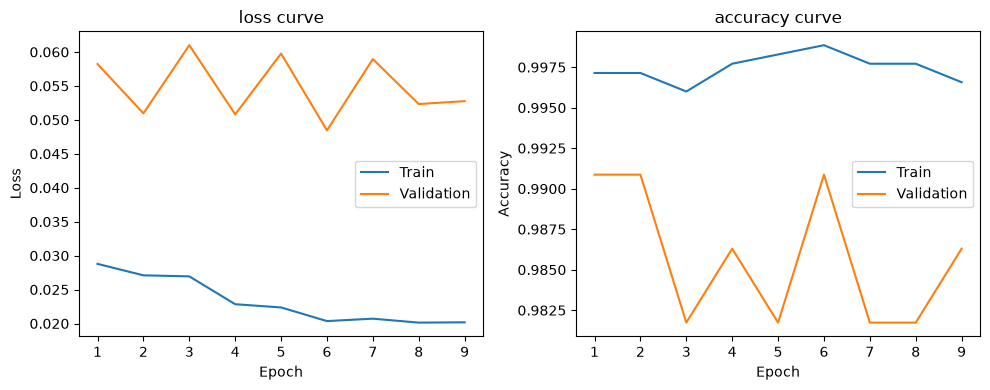

In [95]:
Learning_rate = 0.001
Weight_decay = 0.01
Epochs = 20

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(resnet_model.fc.parameters(), lr=Learning_rate, weight_decay=Weight_decay)

resnet_model = resnet_model.to(device)
for parameter in resnet_model.parameters():
    parameter.requires_grad = False

for parameter in resnet_model.fc.parameters():
    parameter.requires_grad = True
    
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz3.train_one_epoch(resnet_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _, _ = quiz3.evaluate(resnet_model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(resnet_model.state_dict(), "./checkpoints/resnet_best.pt")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Validation loss 連續 3 輪沒有改善，停止訓練。")
        break
    
quiz3.plot_history(history, result_path="./results/resnet")

Test loss：0.0407
Test accuracy：0.9863
Test macro-F1：0.9862


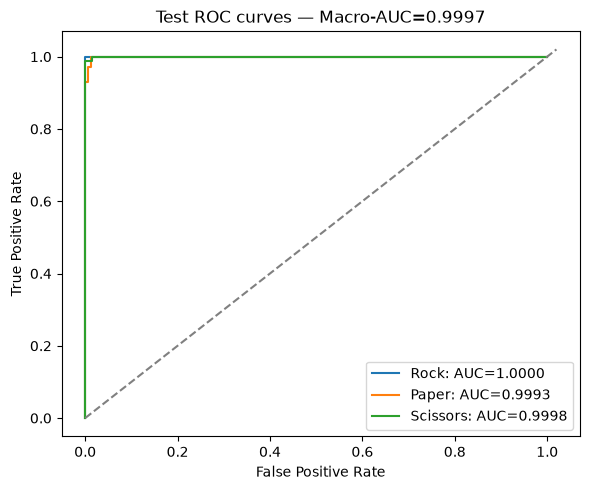

In [96]:
resnet_model.load_state_dict(torch.load("./checkpoints/resnet_best.pt", map_location=device, weights_only=True))
test_loss, test_acc, test_f1, test_auc, y_true, y_prob = quiz3.evaluate(resnet_model, test_loader, criterion, device)

print(f"Test loss：{test_loss:.4f}")
print(f"Test accuracy：{test_acc:.4f}")
print(f"Test macro-F1：{test_f1:.4f}")
quiz3.plot_roc(y_true, y_prob, result_path="./results/resnet")

# quiz 4 基礎